____
# Temporal dependency


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance, compute_variance_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
distance_to_coast_max = 20e3
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('10d', drifter_preprocess, drifter_preprocess_param)

_______
# Generate 

In [3]:
APK = ['swot2km', 'L4_noswot_regional_swottime','L4_noswot_global_swottime','L4_withnadirswot_swottime']

# SURFACE
base_dic = dict(dt='10d', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, {'alti_product_key':apk}) for apk in APK]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',APK)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, {'alti_product_key':apk}) for apk in APK]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',APK)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
#DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSG = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

# Closure figs
dsg = compute_variance(DSG, compute_error='centrallimit')/U2




KeyboardInterrupt



In [5]:
DS.to_zarr(f'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/diag_files/{colocs_sources}_swottime.zarr')

# If already generated 

In [3]:
DS = xr.open_zarr(f'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/diag_files/{colocs_sources}_swottime.zarr').persist()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [4]:
DSG = DS.where(DS.distance_to_coast.compute()>distance_to_coast_max, drop=True)

# Temporal binned

In [7]:
dth = 24 #bin in hours

In [8]:
DSG['time_bin'] = (DSG.time_to_swot/pd.Timedelta('1h')//dth)*dth/24
list_h = np.unique(DSG.time_bin)

D = []
for c in DSG.id_comb :
    dff = DSG.sel(id_comb=c).to_dataframe().reset_index().set_index('row_number')
    D.append(compute_variance_groupby(dff, groupby = 'time_bin', compute_error = 'centrallimit'))
    print(c)
dsg = xr.concat(D, dim='id_comb')
dsg['id_comb'] = DSG.id_comb
dsg.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'{dth}hbin_mean_{colocs_sources}_swottime.nc'))
dsg['time_bin'] = (dsg.time_bin+dth/2/24).assign_attrs({'long_name':r'Temporal mismatch $\Delta T$', 'units':'day'})

time_bin
0.0    588072
1.0    586291
2.0    581047
3.0    580827
4.0    581987
5.0    583420
6.0    584379
7.0    581477
8.0    576518
9.0    572495
Name: acce, dtype: int64
time_bin
0.0    553
1.0    495
2.0    580
3.0    522
4.0    470
5.0    418
6.0    416
7.0    393
8.0    630
9.0    417
dtype: int64
<xarray.DataArray 'id_comb' ()> Size: 108B
array('swot2km', dtype='<U27')
Coordinates:
    id_comb  <U27 108B 'swot2km'
time_bin
0.0    588070
1.0    586289
2.0    581046
3.0    580826
4.0    581986
5.0    583418
6.0    584377
7.0    581475
8.0    576516
9.0    572493
Name: acce, dtype: int64
time_bin
0.0    553
1.0    495
2.0    580
3.0    522
4.0    470
5.0    418
6.0    416
7.0    394
8.0    630
9.0    417
dtype: int64
<xarray.DataArray 'id_comb' ()> Size: 108B
array('L4_noswot_regional_swottime', dtype='<U27')
Coordinates:
    id_comb  <U27 108B 'L4_noswot_regional_swottime'
time_bin
0.0    587302
1.0    585472
2.0    580191
3.0    579965
4.0    581194
5.0    582634
6.0    583554
7

In [9]:
dsg12=dsg

In [10]:
#dsg.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'{dth}hbin_mean_{colocs_sources}.nc'))
dsg12['time_bin'] = (dsg12.time_bin).assign_attrs({'long_name':r'Temporal mismatch $\Delta T$', 'units':'day'})

In [6]:
#dsg1 = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'1hbin_mean_{colocs_sources}.nc'))
dsg12 = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'12hbin_mean_{colocs_sources}.nc'))


FileNotFoundError: [Errno 2] No such file or directory: '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/diag_files/12hbin_mean_10d_spectral_decomp_all_med_variational_10min_v1.nc'

In [ ]:
#dsg12['time_bin'] = dsg12.time_bin+1/4


In [11]:
dsg12['id_comb'] = ['L3-2km', 'L4-regional at SWOT time', 'L4-global at SWOT time', 'L4-SWOT-nadir at SWOT time']

Text(0.5, 1.0, '')

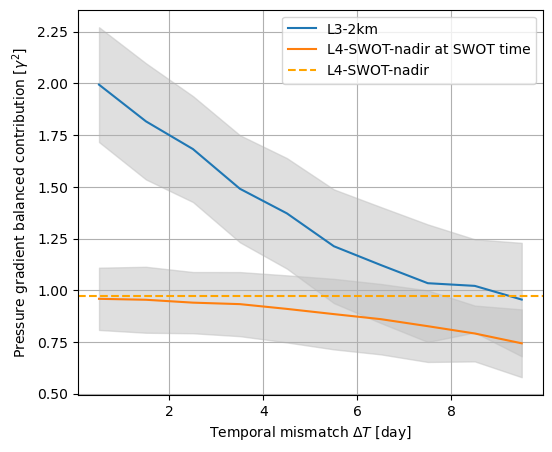

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6,5), frameon=False)
for c in dsg.sel(id_comb = ['L3-2km','L4-SWOT-nadir at SWOT time' ]).id_comb:
    #dsg1.sel(id_comb=c).B_ggd.plot(ax=ax, label = c.values)
    dsg12.sel(id_comb=c).B_ggd.plot(ax=ax, label = c.values)
    #plot_error(dsg1.sel(id_comb=c),'time_bin', 'B_ggd', ax, suf = 'er__')
    plot_error(dsg12.sel(id_comb=c),'time_bin', 'B_ggd', ax, suf = 'er__', alpha=0.5)
ax.axhline(0.97, ls ='--', color='orange', label = 'L4-SWOT-nadir')
ax.set_ylabel(r'Pressure gradient balanced contribution [$\gamma^2$]')
ax.set_xlabel(r'Temporal mismatch $\Delta T$ [day]')
ax.grid()
ax.legend()
ax.set_title('')

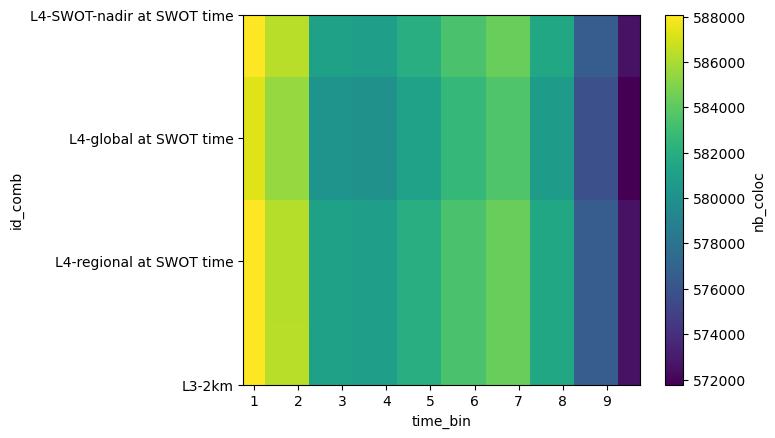

In [30]:
dsg12.nb_coloc.plot()